<a href="https://colab.research.google.com/github/FabioFavre/Pratica-6-PROCSIN/blob/main/Quest%C3%A3o1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Filtros Digitais de 2ª Ordem
Neste notebook, projetaremos filtros digitais (LP, HP, BP e Notch) com $f_s = 20000$ Hz, analisando o efeito do raio dos polos $r$.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000

def analyze_filter(b, a, title, r):
    w, h = signal.freqz(b, a, worN=8000)
    freq = w * fs / (2 * np.pi)
    z, p, k = signal.tf2zpk(b, a)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Resposta em Frequência (Magnitude e Fase Integradas)
    ax1.plot(freq, 20 * np.log10(np.abs(h) + 1e-9), color='b', label='Magnitude (dB)')
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Magnitude (dB)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True)

    ax1b = ax1.twinx()
    ax1b.plot(freq, np.angle(h), color='g', alpha=0.5, label='Fase (rad)')
    ax1b.set_ylabel('Fase (rad)', color='g')
    ax1b.tick_params(axis='y', labelcolor='g')

    ax1.set_title(f'{title} (r={r}) - Resposta em Frequência')

    # Diagrama de Polos e Zeros
    t = np.linspace(0, 2*np.pi, 100)
    ax2.plot(np.cos(t), np.sin(t), 'k--', alpha=0.5)
    ax2.scatter(np.real(z), np.imag(z), s=60, marker='o', edgecolors='b', facecolors='none', label='Zeros')
    ax2.scatter(np.real(p), np.imag(p), s=60, marker='x', color='r', label='Polos')
    ax2.set_title('Diagrama de Polos e Zeros')
    ax2.set_aspect('equal')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

### (a) Passa-baixas com $f_c = 1000$ Hz
Usaremos a forma: $H(z) = G \frac{(1+z^{-1})^2}{1 - 2r\cos(\theta_c)z^{-1} + r^2z^{-2}}$

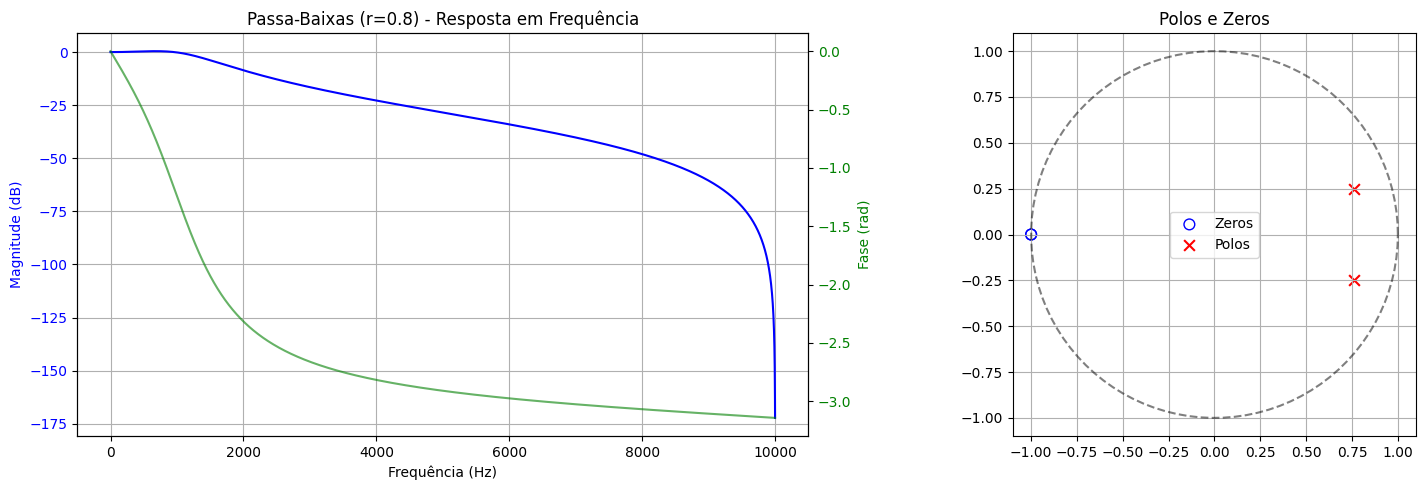

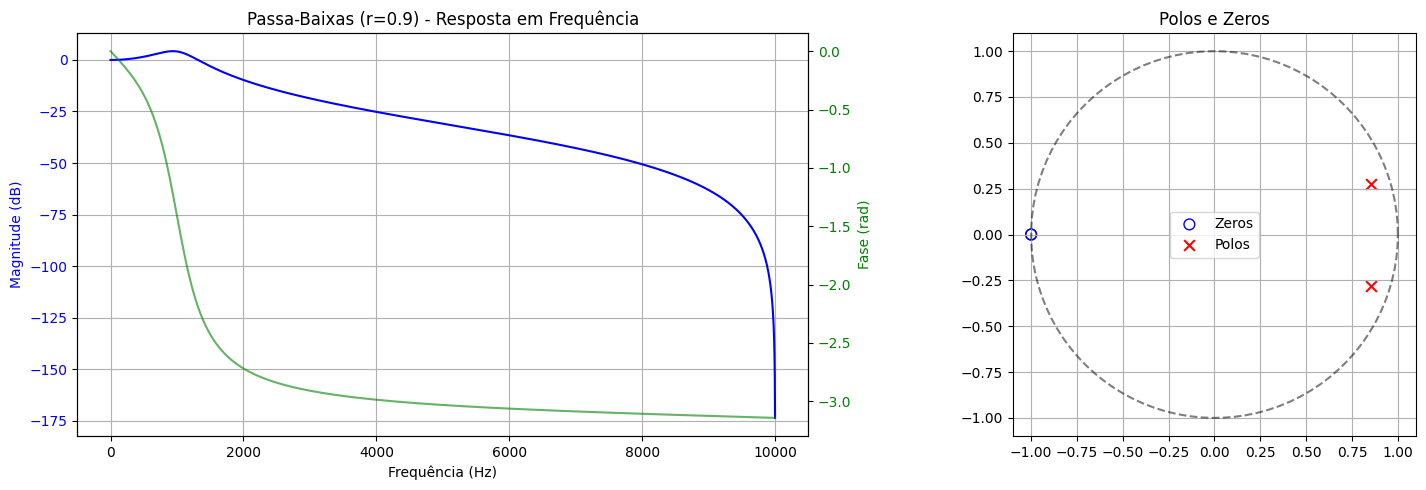

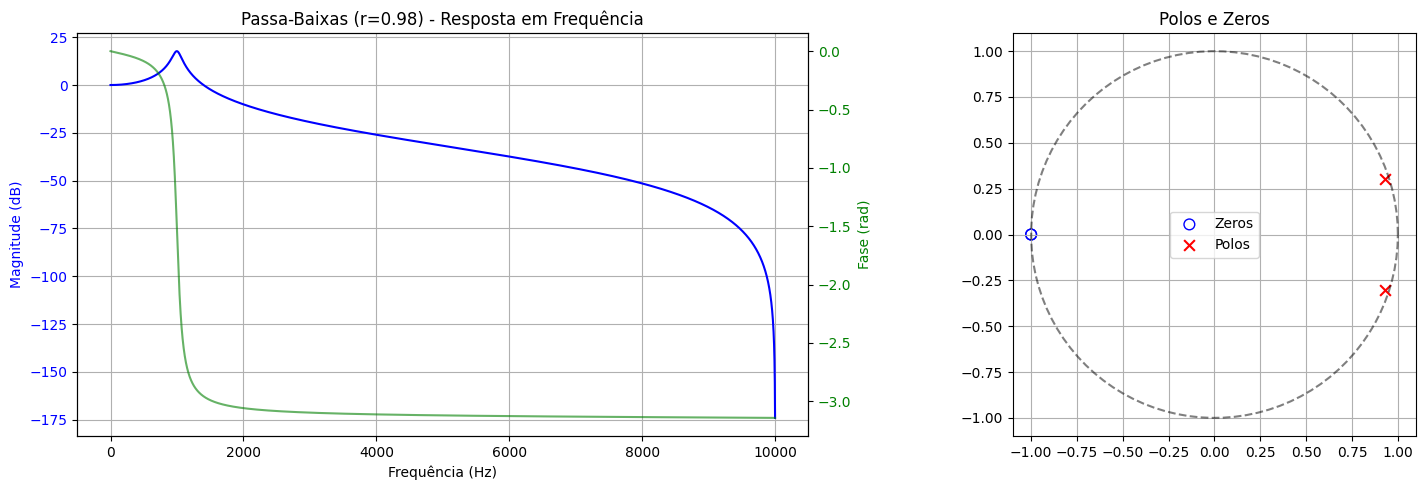

In [13]:
fc = 1000
theta_c = 2 * np.pi * fc / fs
rs = [0.8, 0.9, 0.98]
for r in rs:
    a_lp = [1, -2 * r * np.cos(theta_c), r**2]
    b_unit = [1, 2, 1]
    gain = np.sum(a_lp) / np.sum(b_unit)
    b_lp = [x * gain for x in b_unit]
    analyze_filter(b_lp, a_lp, 'Passa-Baixas', r)

### (b) Passa-altas com $f_c = 2000$ Hz
Forma: $H(z) = G \frac{(1-z^{-1})^2}{1 - 2r\cos(\theta_c)z^{-1} + r^2z^{-2}}$

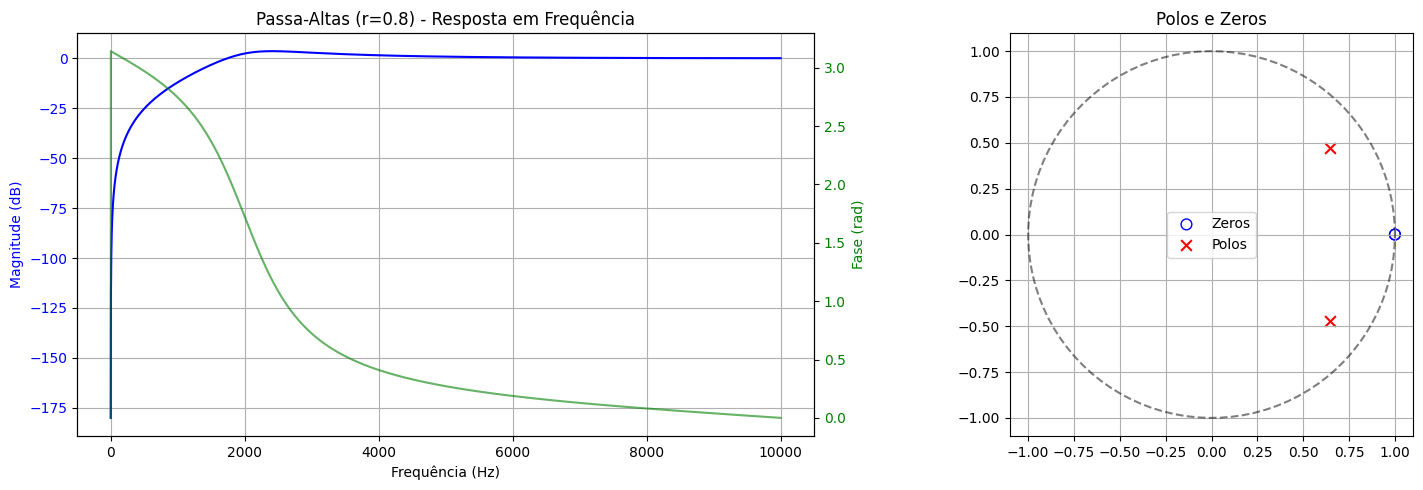

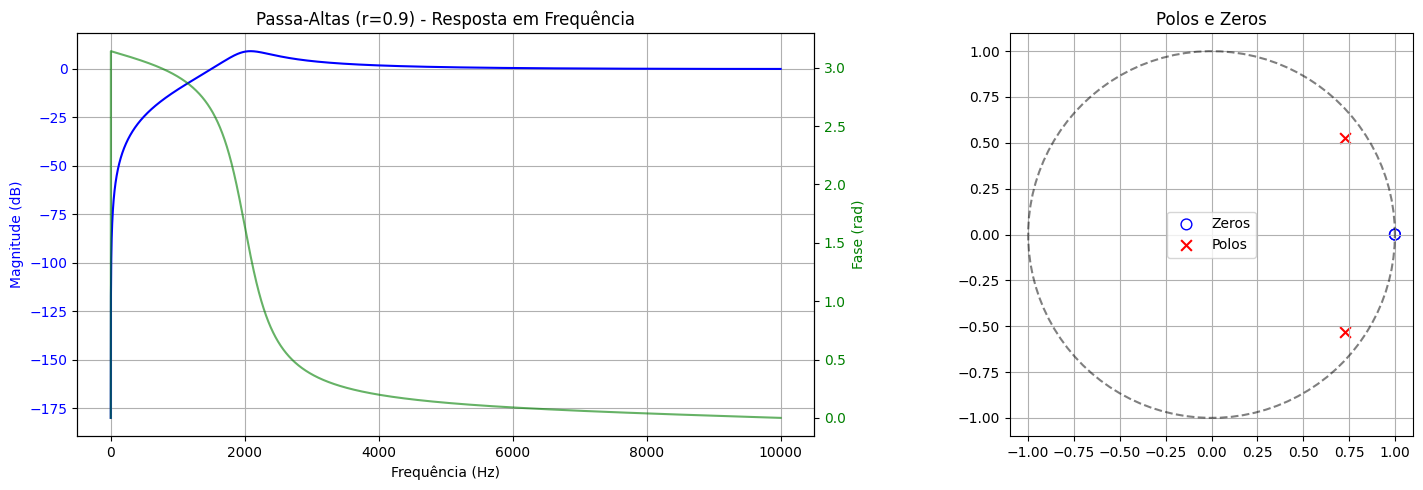

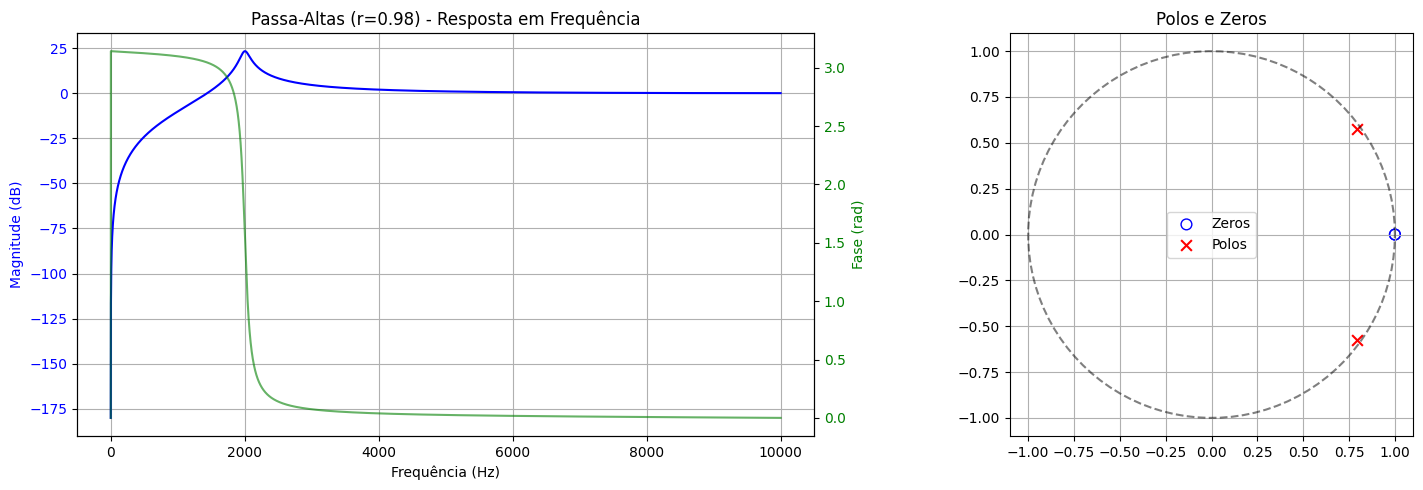

In [14]:
fc = 2000
theta_c = 2 * np.pi * fc / fs
for r in rs:
    a_hp = [1, -2 * r * np.cos(theta_c), r**2]
    b_unit = [1, -2, 1]
    gain = np.abs(np.polyval(a_hp, -1) / np.polyval(b_unit, -1))
    b_hp = [x * gain for x in b_unit]
    analyze_filter(b_hp, a_hp, 'Passa-Altas', r)

### (c) Passa-faixas com $f_c = 7000$ Hz
Forma: $H(z) = G \frac{1-z^{-2}}{1 - 2r\cos(\theta_c)z^{-1} + r^2z^{-2}}$

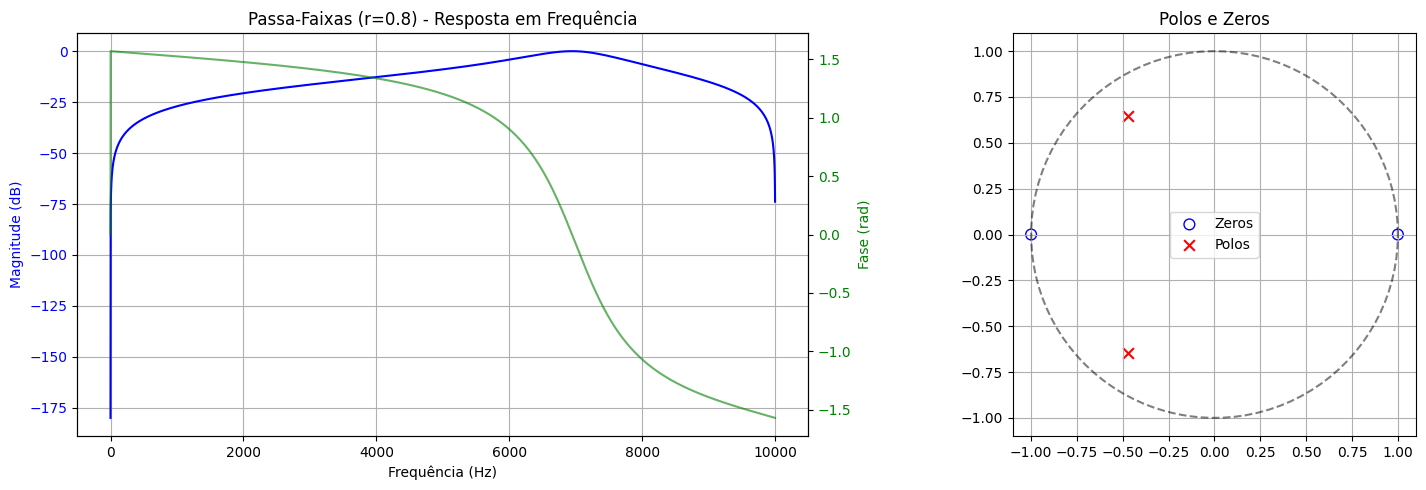

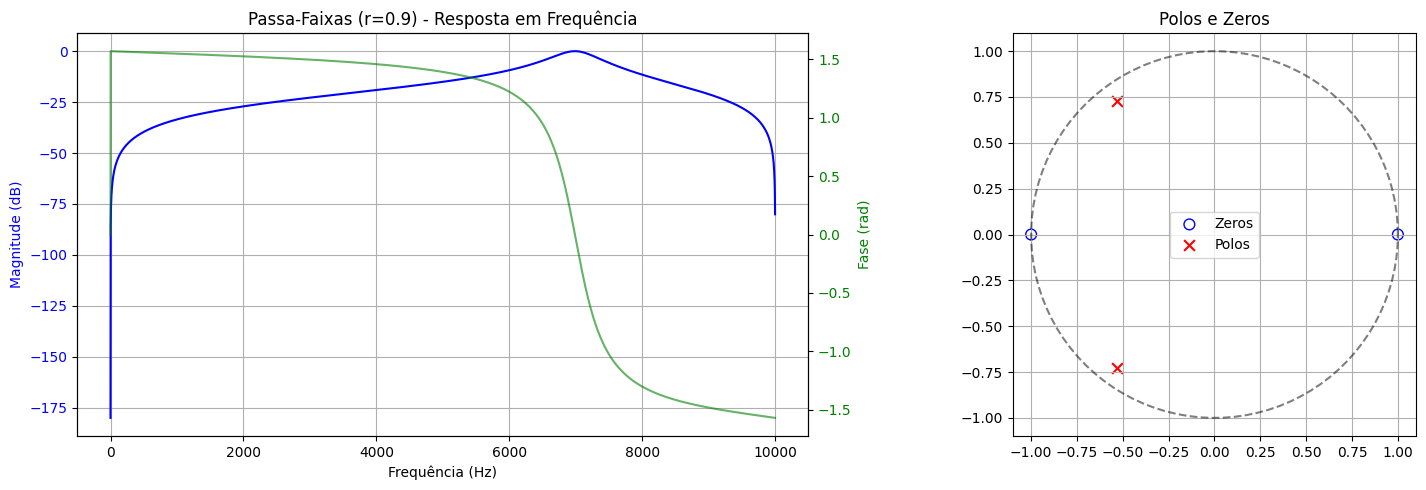

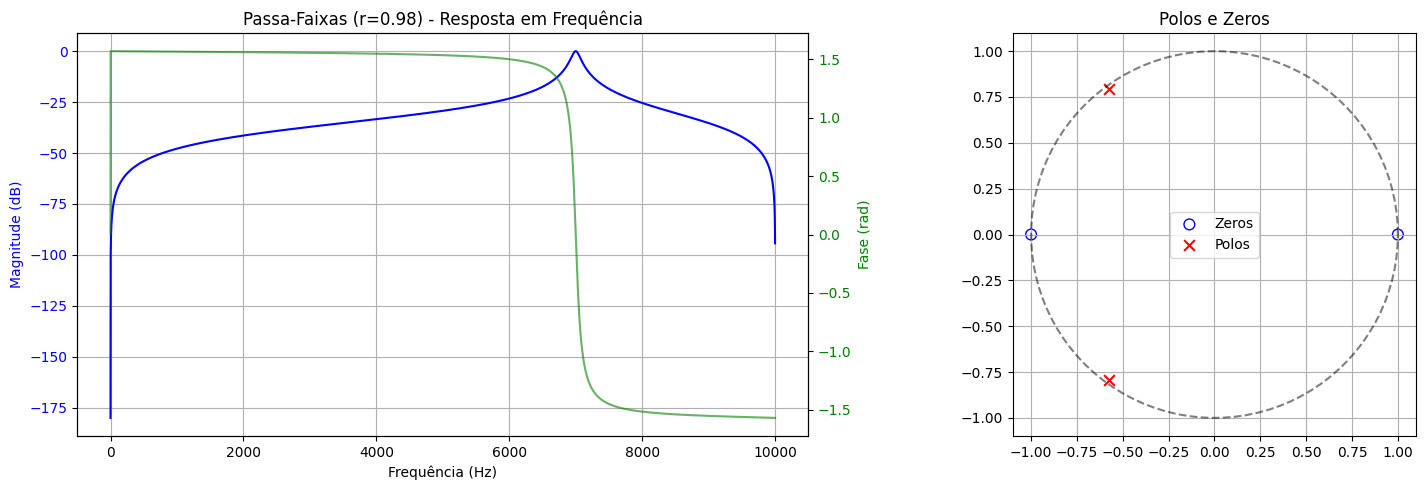

In [15]:
fc = 7000
theta_c = 2 * np.pi * fc / fs
for r in rs:
    a_bp = [1, -2 * r * np.cos(theta_c), r**2]
    b_unit = [1, 0, -1]
    z_c = np.exp(1j * theta_c)
    gain = np.abs(np.polyval(a_bp, z_c) / np.polyval(b_unit, z_c))
    b_bp = [x * gain for x in b_unit]
    analyze_filter(b_bp, a_bp, 'Passa-Faixas', r)

### (d) Notch com $f_c = 3000$ Hz
Forma: $H(z) = G \frac{1 - 2\cos(\theta_c)z^{-1} + z^{-2}}{1 - 2r\cos(\theta_c)z^{-1} + r^2z^{-2}}$

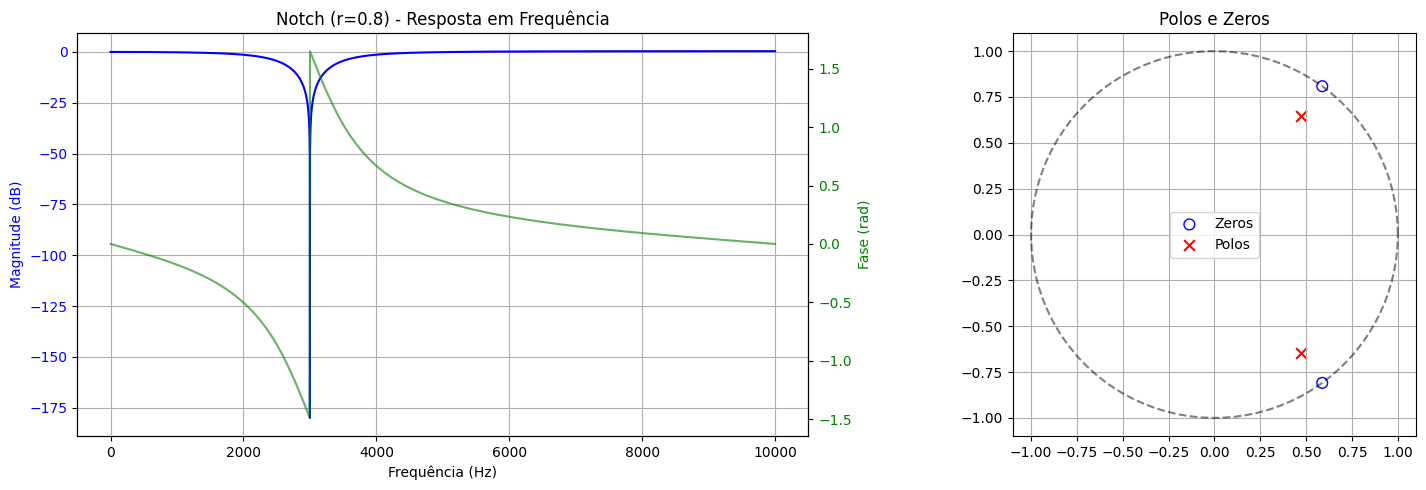

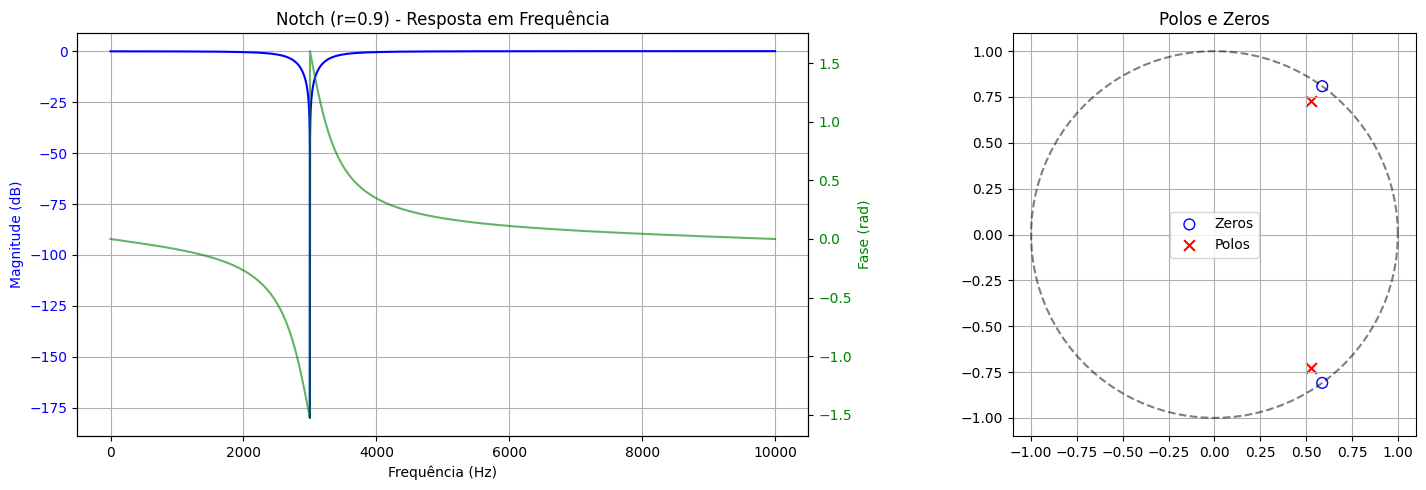

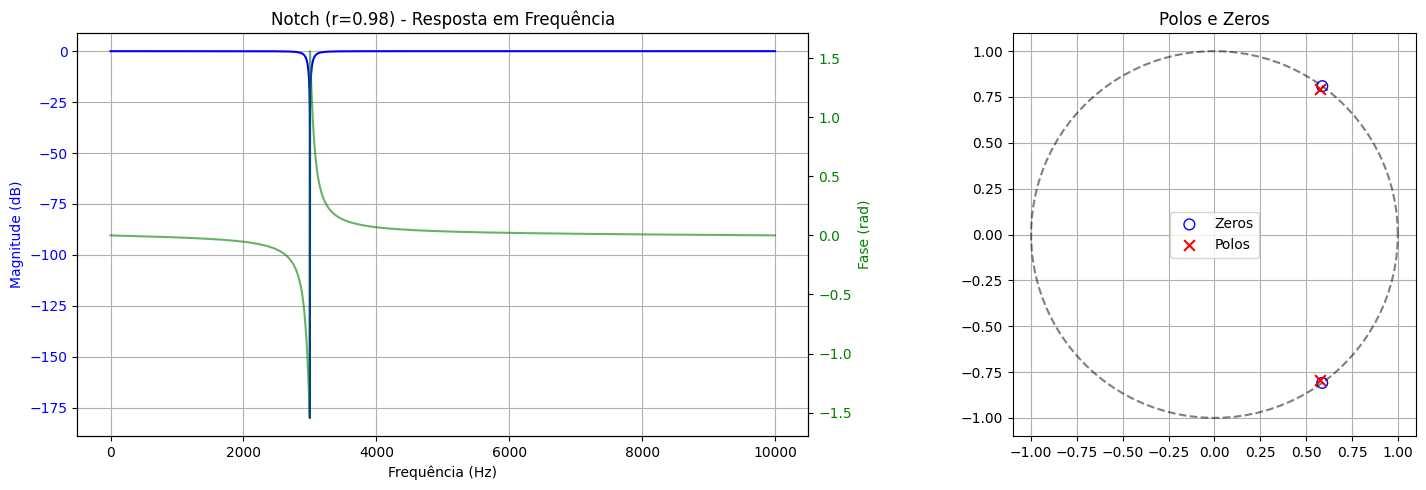

In [16]:
fc = 3000
theta_c = 2 * np.pi * fc / fs
for r in rs:
    a_nt = [1, -2 * r * np.cos(theta_c), r**2]
    b_unit = [1, -2 * np.cos(theta_c), 1]
    gain = np.abs(np.polyval(a_nt, 1) / np.polyval(b_unit, 1))
    b_nt = [x * gain for x in b_unit]
    analyze_filter(b_nt, a_nt, 'Notch', r)